In [1]:
import os
import joblib
from IPython.display import display, Latex

from sklearn.model_selection import RepeatedKFold
from sklearn.metrics import f1_score, multilabel_confusion_matrix, \
    classification_report, accuracy_score, hamming_loss
from scipy.stats import gaussian_kde

import numpy as np
import matplotlib.pyplot as plt

import torch

In [2]:
cwd = os.getcwd()

datasets = ['Chowell_train', 'Chowell_test', 'MSK1', 'MSK2', 'Shim_NSCLC',
            'Kato_panCancer', 'Vanguri_NSCLC', 'Ravi_NSCLC', 'Pradat_panCancer']
datasets_ids = list(range(1, len(datasets) + 1))

# Model trained on each dataset

## Accuracies

### LR vanilla

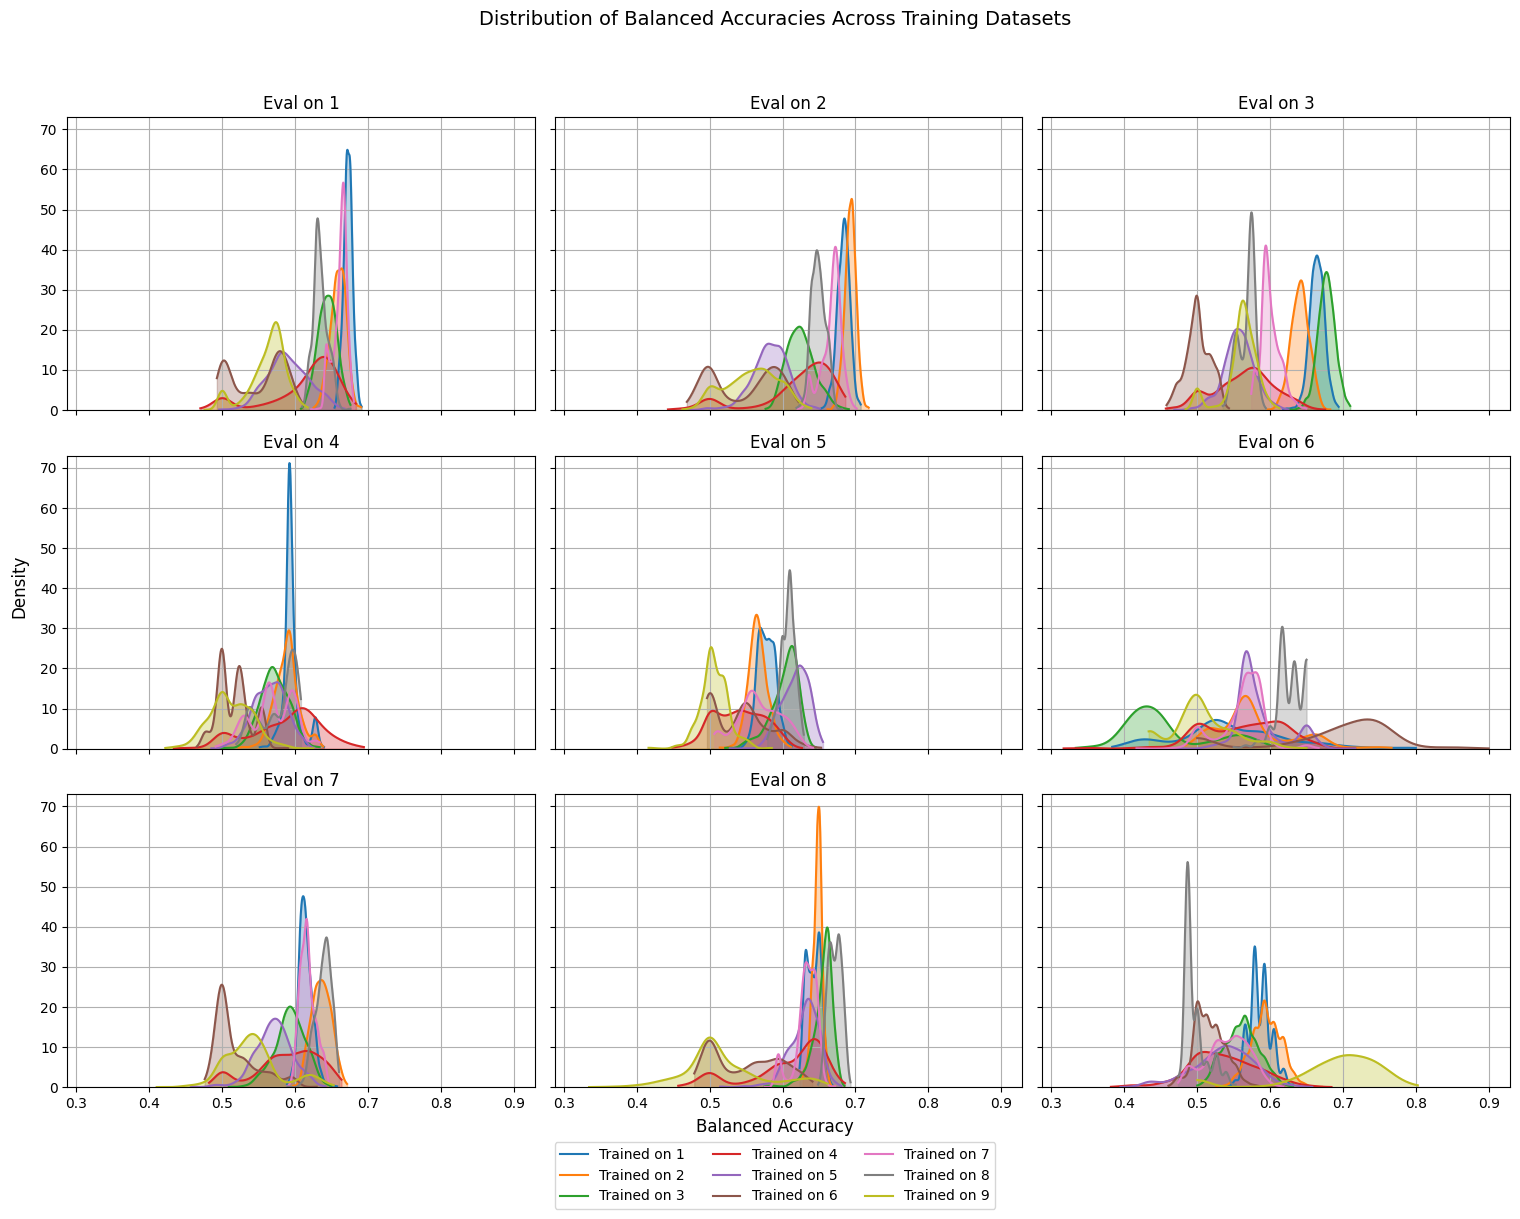

In [3]:
# Config
scaler_type = 'standard'
model_type = 'vanilla'

data_dir = os.path.join(
    cwd, 'results', 'datasets', 'lr',
    scaler_type, model_type, 'params_multilabel.pt'
)
data = torch.load(data_dir, weights_only=True)

colors = plt.cm.tab10.colors  # categorical palette
num_datasets = len(datasets_ids)

# Create 3x3 grid of plots
fig, axes = plt.subplots(3, 3, figsize=(15, 12), sharex=True, sharey=True)
axes = axes.flatten()

for eval_did, ax in enumerate(axes):
    # Loop over training datasets
    ymax = 0
    for train_did in range(num_datasets):
        cond_vector = torch.zeros(num_datasets)
        cond_vector[train_did] = 1
        mask = (data['labels'] == cond_vector).all(dim=1).bool()

        accs = data['bal_accs'][mask]  # (#models, #datasets)
        data_plot = accs[:, eval_did].numpy()

        # KDE
        kde = gaussian_kde(data_plot)
        x = np.linspace(data_plot.min(), data_plot.max(), 200)
        y = kde(x)
        ymax = max(ymax, y.max())

        color = colors[train_did % len(colors)]
        label = f"Trained on {datasets_ids[train_did]}"
        ax.plot(x, y, color=color, label=label)
        ax.fill_between(x, y, alpha=0.3, color=color)

    # Subplot title (evaluation dataset)
    ax.set_title(f"Eval on {datasets_ids[eval_did]}")
    ax.grid(True, zorder=-1)
    ax.set_ylim(0, ymax * 1.3)

# Common labels
fig.text(0.5, 0.045, "Balanced Accuracy", ha='center', fontsize=12)
fig.text(-0.01, 0.5, "Density", va='center', rotation='vertical', fontsize=12)

# Global title
fig.suptitle("Distribution of Balanced Accuracies Across Training Datasets", fontsize=14)

# Common legend below the plots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.025))

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

### LR average

LinAlgError: The data appears to lie in a lower-dimensional subspace of the space in which it is expressed. This has resulted in a singular data covariance matrix, which cannot be treated using the algorithms implemented in `gaussian_kde`. Consider performing principal component analysis / dimensionality reduction and using `gaussian_kde` with the transformed data.

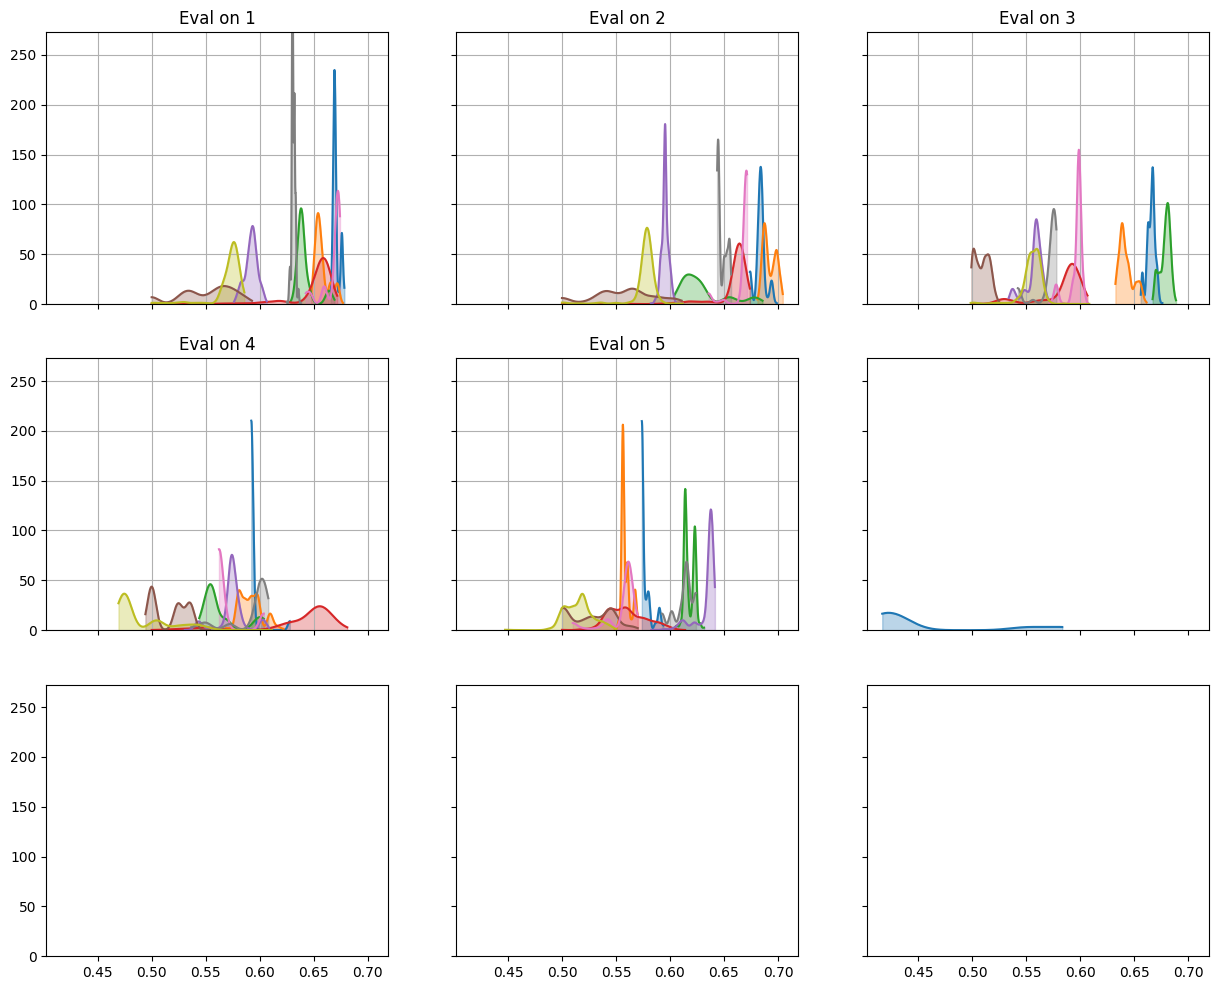

In [4]:
# Config
scaler_type = 'standard'
model_type = 'average'

data_dir = os.path.join(
    cwd, 'results', 'datasets', 'lr',
    scaler_type, model_type, 'params_multilabel.pt'
)
data = torch.load(data_dir, weights_only=True)

colors = plt.cm.tab10.colors  # categorical palette
num_datasets = len(datasets_ids)

# Create 3x3 grid of plots
fig, axes = plt.subplots(3, 3, figsize=(15, 12), sharex=True, sharey=True)
axes = axes.flatten()

for eval_did, ax in enumerate(axes):
    # Loop over training datasets
    ymax = 0
    for train_did in range(num_datasets):
        cond_vector = torch.zeros(num_datasets)
        cond_vector[train_did] = 1
        mask = (data['labels'] == cond_vector).all(dim=1).bool()

        accs = data['bal_accs'][mask]  # (#models, #datasets)
        data_plot = accs[:, eval_did].numpy()

        # KDE
        kde = gaussian_kde(data_plot)
        x = np.linspace(data_plot.min(), data_plot.max(), 200)
        y = kde(x)
        ymax = max(ymax, y.max())

        color = colors[train_did % len(colors)]
        label = f"Trained on {datasets_ids[train_did]}"
        ax.plot(x, y, color=color, label=label)
        ax.fill_between(x, y, alpha=0.3, color=color)

    # Subplot title (evaluation dataset)
    ax.set_title(f"Eval on {datasets_ids[eval_did]}")
    ax.grid(True, zorder=-1)
    ax.set_ylim(0, ymax * 1.3)

# Common labels
fig.text(0.5, 0.045, "Balanced Accuracy", ha='center', fontsize=12)
fig.text(-0.01, 0.5, "Density", va='center', rotation='vertical', fontsize=12)

# Global title
fig.suptitle("Distribution of Balanced Accuracies Across Training Datasets", fontsize=14)

# Common legend below the plots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.025))

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

### TT vanilla

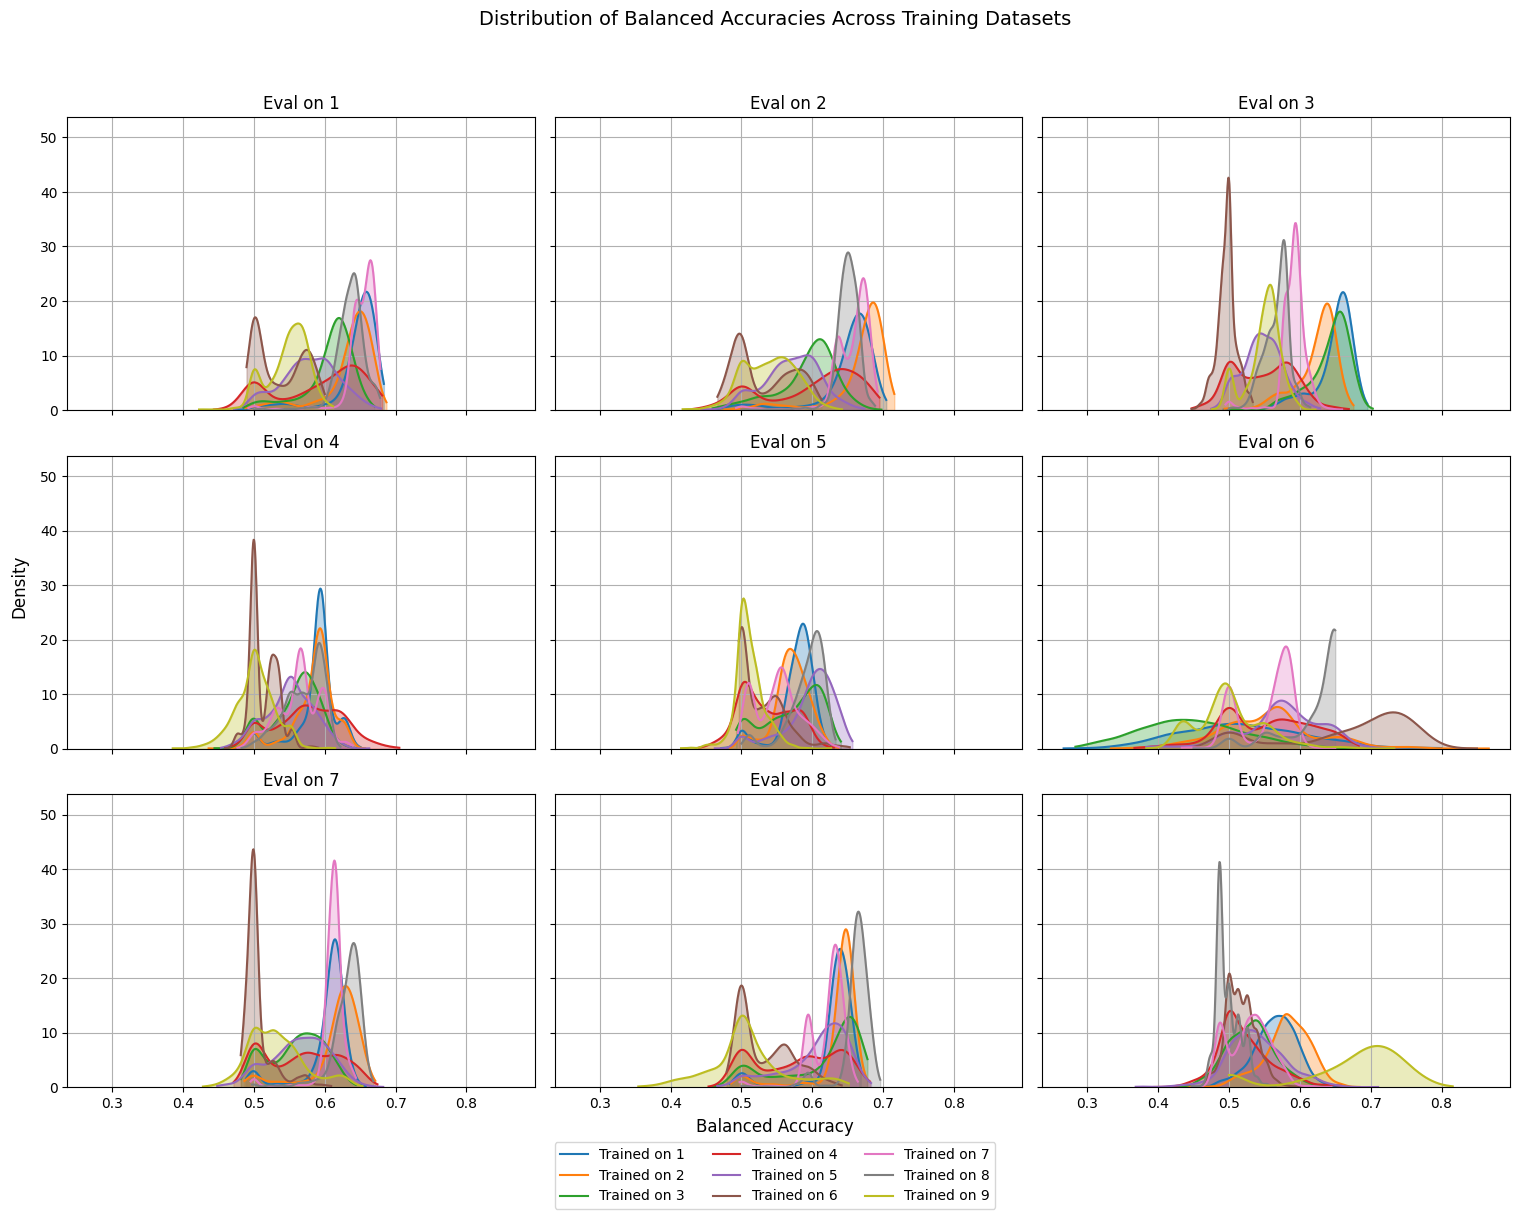

In [6]:
# Config
scaler_type = 'standard'
model_type = 'vanilla'

data_dir = os.path.join(
    cwd, 'results', 'datasets', 'tt',
    scaler_type, model_type, 'params_multilabel.pt'
)
data = torch.load(data_dir, weights_only=True)

colors = plt.cm.tab10.colors  # categorical palette
num_datasets = len(datasets_ids)

# Create 3x3 grid of plots
fig, axes = plt.subplots(3, 3, figsize=(15, 12), sharex=True, sharey=True)
axes = axes.flatten()

for eval_did, ax in enumerate(axes):
    # Loop over training datasets
    ymax = 0
    for train_did in range(num_datasets):
        cond_vector = torch.zeros(num_datasets)
        cond_vector[train_did] = 1
        mask = (data['labels'] == cond_vector).all(dim=1).bool()

        accs = data['bal_accs'][mask]  # (#models, #datasets)
        data_plot = accs[:, eval_did].numpy()

        # KDE
        kde = gaussian_kde(data_plot)
        x = np.linspace(data_plot.min(), data_plot.max(), 200)
        y = kde(x)
        ymax = max(ymax, y.max())

        color = colors[train_did % len(colors)]
        label = f"Trained on {datasets_ids[train_did]}"
        ax.plot(x, y, color=color, label=label)
        ax.fill_between(x, y, alpha=0.3, color=color)

    # Subplot title (evaluation dataset)
    ax.set_title(f"Eval on {datasets_ids[eval_did]}")
    ax.grid(True, zorder=-1)
    ax.set_ylim(0, ymax * 1.3)

# Common labels
fig.text(0.5, 0.045, "Balanced Accuracy", ha='center', fontsize=12)
fig.text(-0.01, 0.5, "Density", va='center', rotation='vertical', fontsize=12)

# Global title
fig.suptitle("Distribution of Balanced Accuracies Across Training Datasets", fontsize=14)

# Common legend below the plots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.025))

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

## Attacks

### Weak Black-Box

In [13]:
attack_name = 'weak'
scaler_type = 'standard'

for model_type in ['vanilla', 'average']:
    print(f'{model_type}:')
    for model_name in ['lr', 'lr_priv', 'tt']:
        attacker_dir = os.path.join(cwd, 'results', 'attacks', 'bb', model_name,
                                    scaler_type, model_type)
        
        data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                                scaler_type, model_type, 'params_multilabel.pt')
        data = torch.load(data_dir, weights_only=True)
        
        X, y = data['bin_scores'], data['labels']
        
        mask = torch.zeros(X.size(0), dtype=torch.bool)
        for i in range(num_datasets):
            cond_vector = torch.zeros(num_datasets)
            cond_vector[i] = 1
            mask = torch.logical_or(mask,
                                    (data['labels'] == cond_vector).all(dim=1))
        
        n_splits = 5
        n_repeats = 5
        repkfold = RepeatedKFold(n_splits=n_splits,
                                 n_repeats=n_repeats,
                                 random_state=1)
        
        values = []
        for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
            mlp_bb = joblib.load(
                os.path.join(attacker_dir,
                             f'mlp_bb_{attack_name}_{i+1}.pkl'))
            
            aux_mask = mask[test_idx]
            X_test, y_test = X[test_idx][aux_mask], y[test_idx][aux_mask]
            
            y_pred = mlp_bb.predict(X_test)
            val = 1 - hamming_loss(y_test, y_pred)
            values.append(val)
        
        values = torch.tensor(values)
        print(f'Ham. Acc. {model_name}: mean = {values.mean():.4f}, std = {values.std():.4f}')
    print()

vanilla:
Ham. Acc. lr: mean = 0.9187, std = 0.0170
Ham. Acc. lr_priv: mean = 0.9127, std = 0.0112
Ham. Acc. tt: mean = 0.8431, std = 0.0091

average:
Ham. Acc. lr: mean = 0.9606, std = 0.0173
Ham. Acc. lr_priv: mean = 0.9438, std = 0.0086
Ham. Acc. tt: mean = 0.8721, std = 0.0142



### Strong Black-Box

In [14]:
attack_name = 'strong'
scaler_type = 'standard'

for model_type in ['vanilla', 'average']:
    print(f'{model_type}:')
    for model_name in ['lr', 'lr_priv', 'tt']:
        attacker_dir = os.path.join(cwd, 'results', 'attacks', 'bb', model_name,
                                    scaler_type, model_type)
        
        data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                                scaler_type, model_type, 'params_multilabel.pt')
        data = torch.load(data_dir, weights_only=True)
        
        X, y = data['out_scores'], data['labels']
        
        mask = torch.zeros(X.size(0), dtype=torch.bool)
        for i in range(num_datasets):
            cond_vector = torch.zeros(num_datasets)
            cond_vector[i] = 1
            mask = torch.logical_or(mask,
                                    (data['labels'] == cond_vector).all(dim=1))
        
        n_splits = 5
        n_repeats = 5
        repkfold = RepeatedKFold(n_splits=n_splits,
                                 n_repeats=n_repeats,
                                 random_state=1)
        
        values = []
        for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
            mlp_bb = joblib.load(
                os.path.join(attacker_dir,
                            f'mlp_bb_{attack_name}_{i+1}.pkl'))
            
            aux_mask = mask[test_idx]
            X_test, y_test = X[test_idx][aux_mask], y[test_idx][aux_mask]
            
            y_pred = mlp_bb.predict(X_test)
            val = 1 - hamming_loss(y_test, y_pred)
            values.append(val)
        
        values = torch.tensor(values)
        print(f'Ham. Acc. {model_name}: mean = {values.mean():.4f}, std = {values.std():.4f}')
    print()

vanilla:
Ham. Acc. lr: mean = 0.8990, std = 0.0419
Ham. Acc. lr_priv: mean = 0.9343, std = 0.0142
Ham. Acc. tt: mean = 0.8657, std = 0.0283

average:
Ham. Acc. lr: mean = 0.9272, std = 0.0593
Ham. Acc. lr_priv: mean = 0.9722, std = 0.0223
Ham. Acc. tt: mean = 0.8868, std = 0.0362



### White-Box

In [15]:
scaler_type = 'standard'

for model_type in ['vanilla', 'average']:
    print(f'{model_type}:')
    for model_name in ['lr', 'lr_priv', 'tt']:
        attacker_dir = os.path.join(cwd, 'results', 'attacks', 'wb', model_name,
                                    scaler_type, model_type)
        
        data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                                scaler_type, model_type, 'params_multilabel.pt')
        data = torch.load(data_dir, weights_only=True)
        
        if model_name == 'tt':
            X, y = data['cores'], data['labels']
        else:
            X, y = data['params'], data['labels']
        
        mask = torch.zeros(X.size(0), dtype=torch.bool)
        for i in range(num_datasets):
            cond_vector = torch.zeros(num_datasets)
            cond_vector[i] = 1
            mask = torch.logical_or(mask,
                                    (data['labels'] == cond_vector).all(dim=1))
        
        n_splits = 5
        n_repeats = 5
        repkfold = RepeatedKFold(n_splits=n_splits,
                                 n_repeats=n_repeats,
                                 random_state=1)
        
        values = []
        for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
            # Load models
            n_splits = 5
            loaded_models = []
            
            # Load each model
            for j in range(n_splits):
                mlp_wb = joblib.load(os.path.join(attacker_dir,
                                                  f'mlp_wb_fold_{j+1}_{i+1}.pkl'))
                loaded_models.append(mlp_wb)
            
            aux_mask = mask[test_idx]
            X_test, y_test = X[test_idx][aux_mask], y[test_idx][aux_mask]
            
            all_preds = np.array([model.predict_proba(X_test)
                                  for model in loaded_models])
            avg_preds = np.mean(all_preds, axis=0)
            y_pred = (avg_preds >= 0.5).astype(int)
            
            val = 1 - hamming_loss(y_test, y_pred)
            values.append(val)
        
        values = torch.tensor(values)
        print(f'Ham. Acc. {model_name}: mean = {values.mean():.4f}, std = {values.std():.4f}')
    print()

vanilla:
Ham. Acc. lr: mean = 0.9096, std = 0.0079
Ham. Acc. lr_priv: mean = 0.9385, std = 0.0047
Ham. Acc. tt: mean = 0.5540, std = 0.1217

average:
Ham. Acc. lr: mean = 0.9923, std = 0.0075
Ham. Acc. lr_priv: mean = 0.9719, std = 0.0110
Ham. Acc. tt: mean = 0.6083, std = 0.0915



In [16]:
scaler_type = 'standard'

for model_type in ['vanilla', 'average']:
    print(f'{model_type}:')
    attacker_dir = os.path.join(cwd, 'results', 'attacks', 'wb', 'lr_tt',
                                scaler_type, model_type)
    
    data_dir = os.path.join(cwd, 'results', 'datasets', 'tt',
                            scaler_type, model_type, 'params_multilabel.pt')
    data = torch.load(data_dir, weights_only=True)
    
    X, y = data['lr_params'], data['labels']
    
    # Avoid NaNs and infs in lr_tt params
    mask = ~X.isnan().any(dim=1)
    mask = mask * ~X.isinf().any(dim=1)
    
    aux_mask = torch.zeros(X.size(0), dtype=torch.bool)
    for i in range(num_datasets):
        cond_vector = torch.zeros(num_datasets)
        cond_vector[i] = 1
        aux_mask = torch.logical_or(aux_mask,
                                    (data['labels'] == cond_vector).all(dim=1))
    mask = mask * aux_mask
    
    n_splits = 5
    n_repeats = 5
    repkfold = RepeatedKFold(n_splits=n_splits,
                             n_repeats=n_repeats,
                             random_state=1)
    
    values = []
    for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
        # Load models
        n_splits = 5
        loaded_models = []
        
        # Load each model
        for j in range(n_splits):
            mlp_wb = joblib.load(os.path.join(attacker_dir,
                                                f'mlp_wb_fold_{j+1}_{i+1}.pkl'))
            loaded_models.append(mlp_wb)
        
        aux_mask = mask[test_idx]
        X_test, y_test = X[test_idx][aux_mask], y[test_idx][aux_mask]
        
        all_preds = np.array([model.predict_proba(X_test)
                                for model in loaded_models])
        avg_preds = np.mean(all_preds, axis=0)
        y_pred = (avg_preds >= 0.5).astype(int)
        
        val = 1 - hamming_loss(y_test, y_pred)
        values.append(val)
    
    values = torch.tensor(values)
    print(f'Ham. Acc. lr_tt: mean = {values.mean():.4f}, std = {values.std():.4f}')
print()

vanilla:
Ham. Acc. lr_tt: mean = 0.7848, std = 0.0154
average:
Ham. Acc. lr_tt: mean = 0.7889, std = 0.0306



# Model trained on datasets that contains each dataset

## Accuracies

### LR vanilla

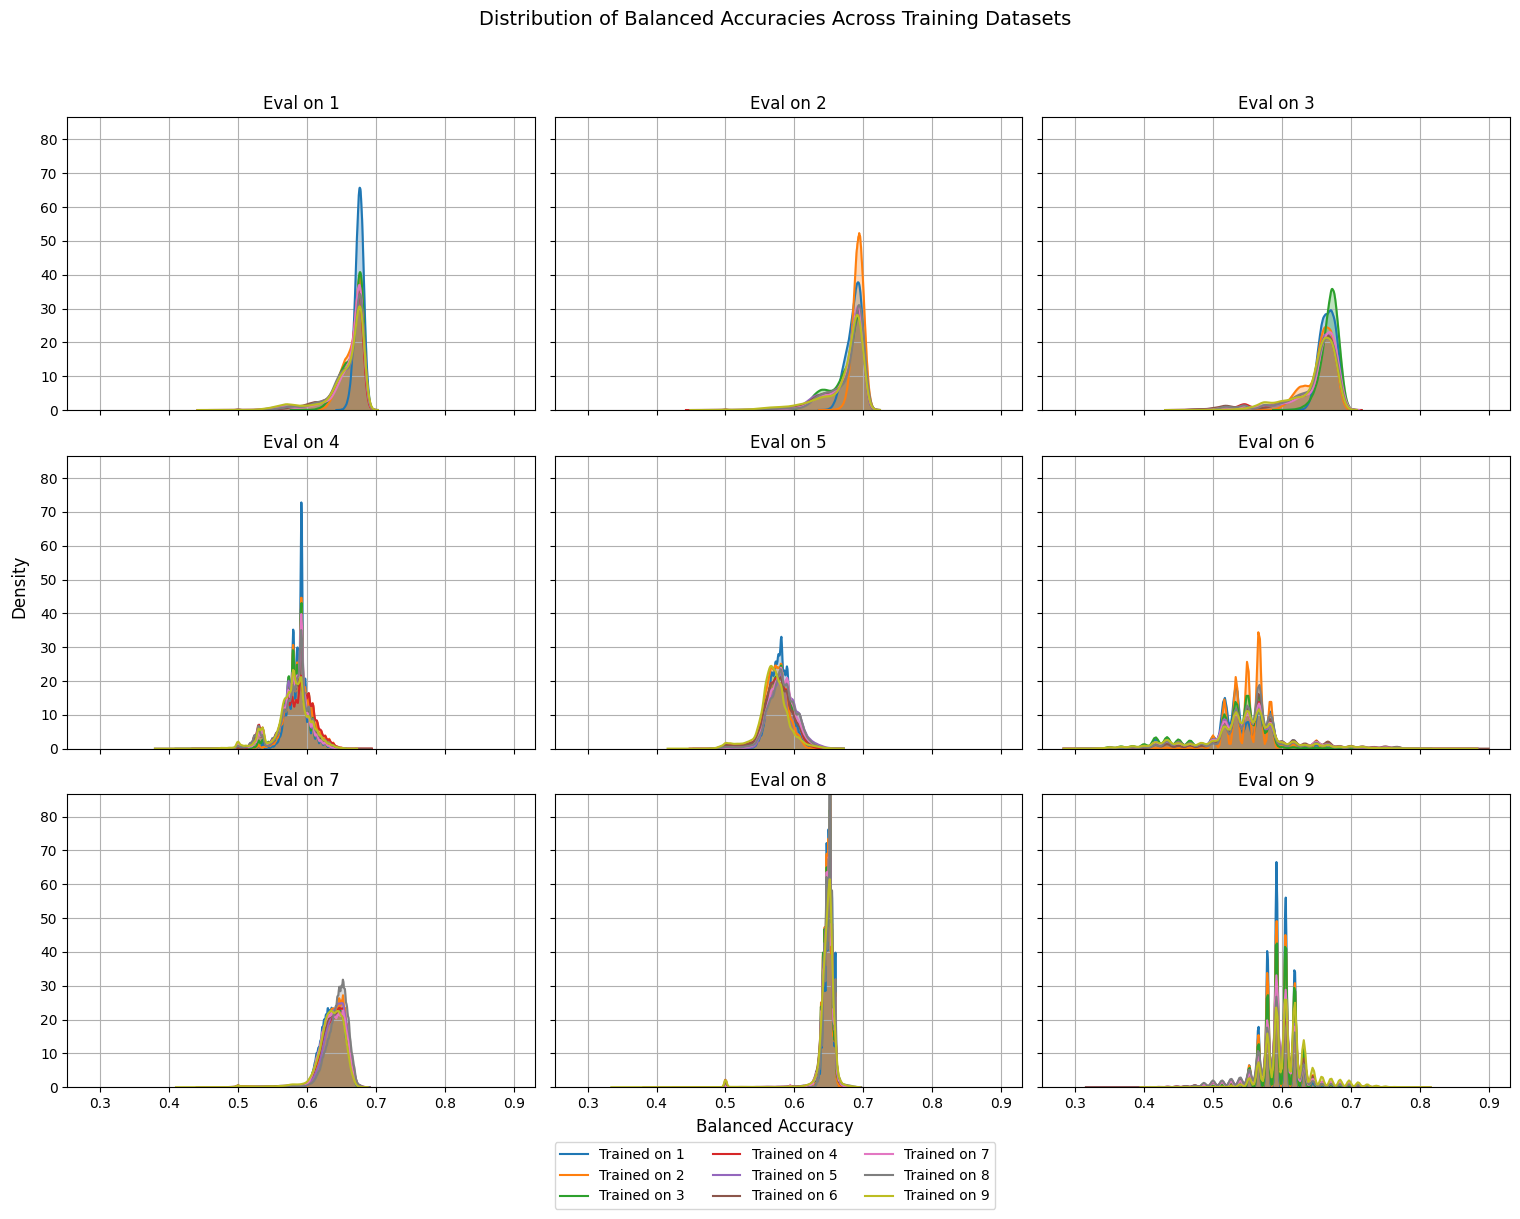

In [23]:
# Config
scaler_type = 'standard'
model_type = 'vanilla'

data_dir = os.path.join(
    cwd, 'results', 'datasets', 'lr',
    scaler_type, model_type, 'params_multilabel.pt'
)
data = torch.load(data_dir, weights_only=True)

colors = plt.cm.tab10.colors  # categorical palette
num_datasets = len(datasets_ids)

# Create 3x3 grid of plots
fig, axes = plt.subplots(3, 3, figsize=(15, 12), sharex=True, sharey=True)
axes = axes.flatten()

for eval_did, ax in enumerate(axes):
    # Loop over training datasets
    ymax = 0
    for train_did in range(num_datasets):
        mask = data['labels'][:, train_did] == 1

        accs = data['bal_accs'][mask]  # (#models, #datasets)
        data_plot = accs[:, eval_did].numpy()

        # KDE
        kde = gaussian_kde(data_plot)
        x = np.linspace(data_plot.min(), data_plot.max(), 200)
        y = kde(x)
        ymax = max(ymax, y.max())

        color = colors[train_did % len(colors)]
        label = f"Trained on {datasets_ids[train_did]}"
        ax.plot(x, y, color=color, label=label)
        ax.fill_between(x, y, alpha=0.3, color=color)

    # Subplot title (evaluation dataset)
    ax.set_title(f"Eval on {datasets_ids[eval_did]}")
    ax.grid(True, zorder=-1)
    ax.set_ylim(0, ymax * 1.3)

# Common labels
fig.text(0.5, 0.045, "Balanced Accuracy", ha='center', fontsize=12)
fig.text(-0.01, 0.5, "Density", va='center', rotation='vertical', fontsize=12)

# Global title
fig.suptitle("Distribution of Balanced Accuracies Across Training Datasets", fontsize=14)

# Common legend below the plots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.025))

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

### LR average

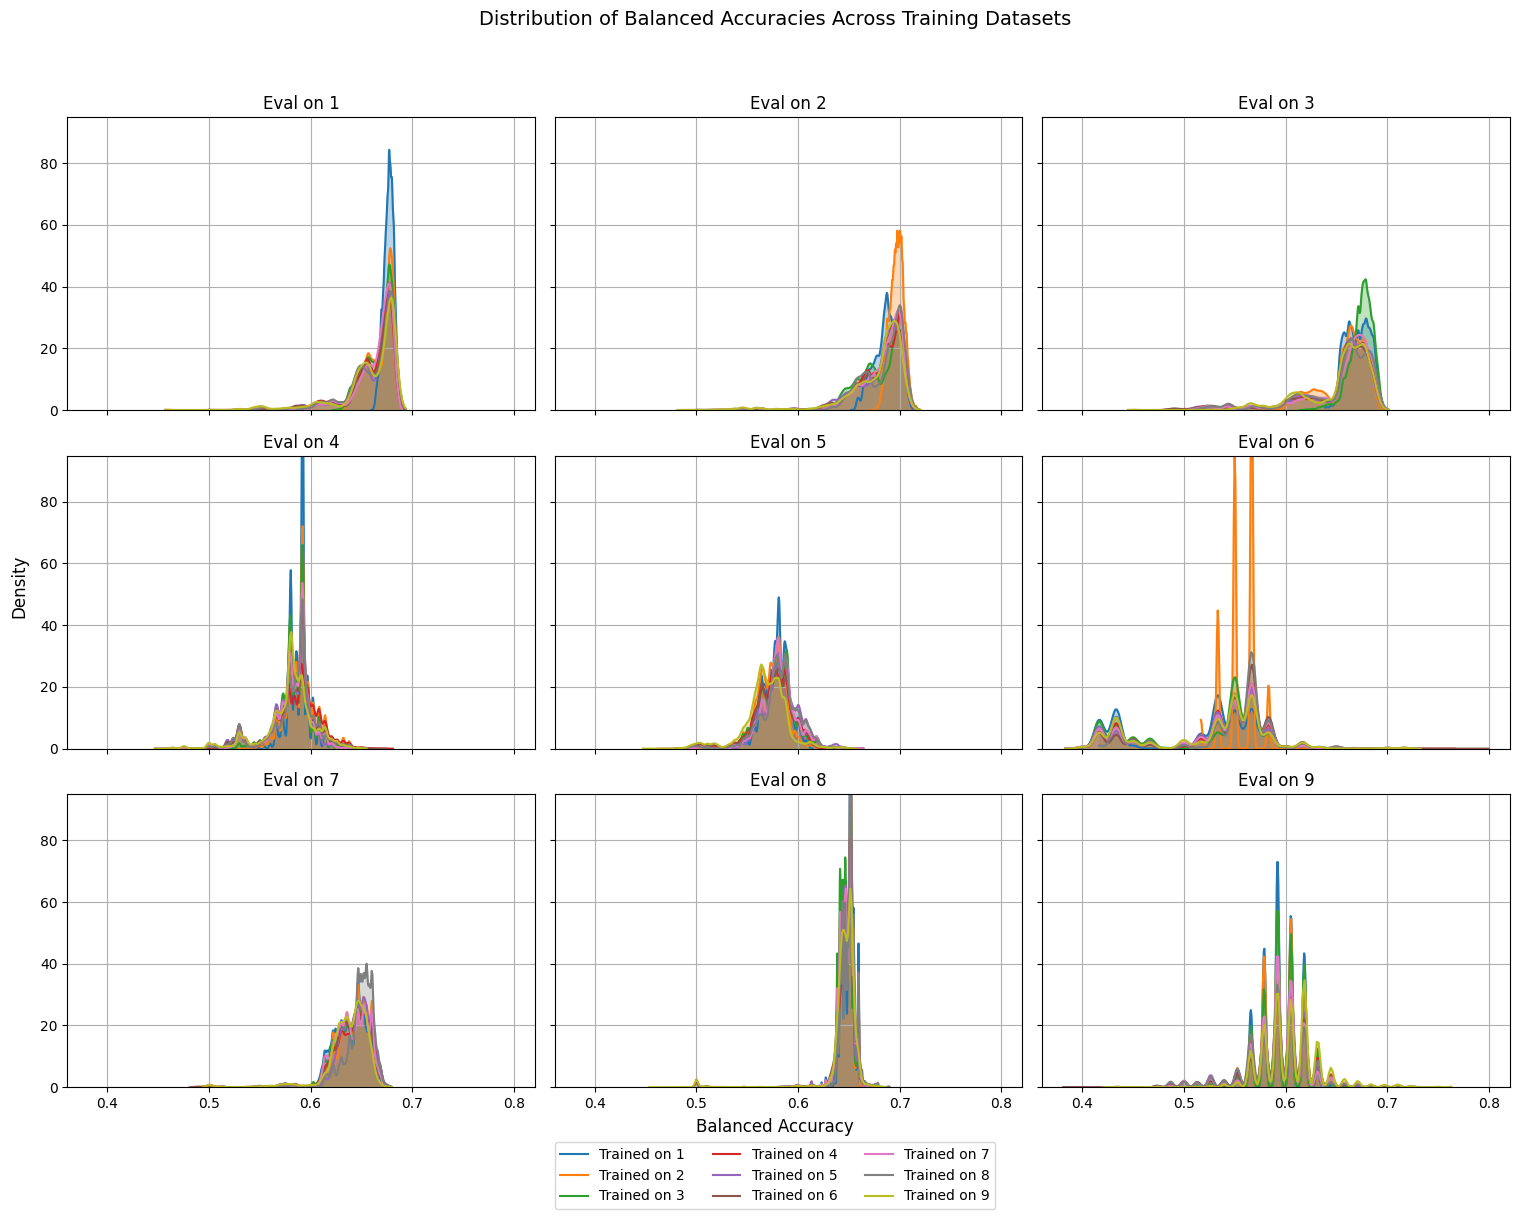

In [24]:
# Config
scaler_type = 'standard'
model_type = 'average'

data_dir = os.path.join(
    cwd, 'results', 'datasets', 'lr',
    scaler_type, model_type, 'params_multilabel.pt'
)
data = torch.load(data_dir, weights_only=True)

colors = plt.cm.tab10.colors  # categorical palette
num_datasets = len(datasets_ids)

# Create 3x3 grid of plots
fig, axes = plt.subplots(3, 3, figsize=(15, 12), sharex=True, sharey=True)
axes = axes.flatten()

for eval_did, ax in enumerate(axes):
    # Loop over training datasets
    ymax = 0
    for train_did in range(num_datasets):
        mask = data['labels'][:, train_did] == 1

        accs = data['bal_accs'][mask]  # (#models, #datasets)
        data_plot = accs[:, eval_did].numpy()

        # KDE
        kde = gaussian_kde(data_plot)
        x = np.linspace(data_plot.min(), data_plot.max(), 200)
        y = kde(x)
        ymax = max(ymax, y.max())

        color = colors[train_did % len(colors)]
        label = f"Trained on {datasets_ids[train_did]}"
        ax.plot(x, y, color=color, label=label)
        ax.fill_between(x, y, alpha=0.3, color=color)

    # Subplot title (evaluation dataset)
    ax.set_title(f"Eval on {datasets_ids[eval_did]}")
    ax.grid(True, zorder=-1)
    ax.set_ylim(0, ymax * 1.3)

# Common labels
fig.text(0.5, 0.045, "Balanced Accuracy", ha='center', fontsize=12)
fig.text(-0.01, 0.5, "Density", va='center', rotation='vertical', fontsize=12)

# Global title
fig.suptitle("Distribution of Balanced Accuracies Across Training Datasets", fontsize=14)

# Common legend below the plots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.025))

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

### TT vanilla

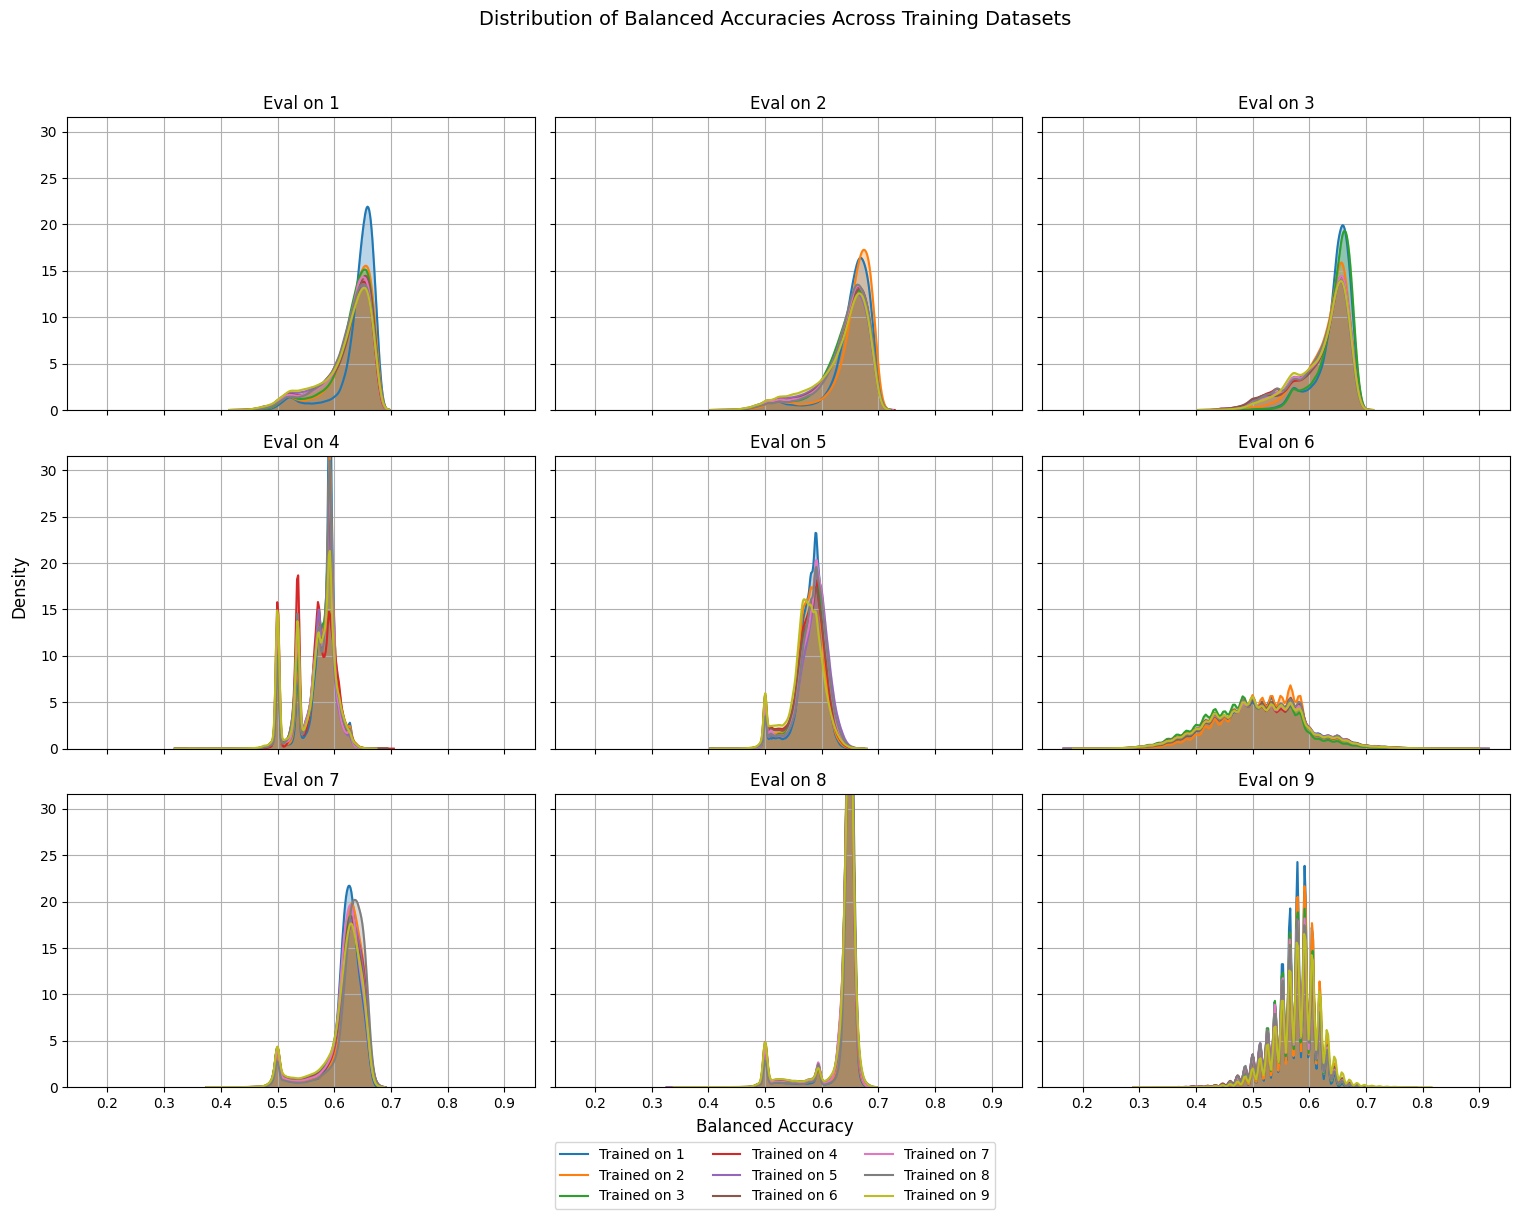

In [25]:
# Config
scaler_type = 'standard'
model_type = 'vanilla'

data_dir = os.path.join(
    cwd, 'results', 'datasets', 'tt',
    scaler_type, model_type, 'params_multilabel.pt'
)
data = torch.load(data_dir, weights_only=True)

colors = plt.cm.tab10.colors  # categorical palette
num_datasets = len(datasets_ids)

# Create 3x3 grid of plots
fig, axes = plt.subplots(3, 3, figsize=(15, 12), sharex=True, sharey=True)
axes = axes.flatten()

for eval_did, ax in enumerate(axes):
    # Loop over training datasets
    ymax = 0
    for train_did in range(num_datasets):
        mask = data['labels'][:, train_did] == 1

        accs = data['bal_accs'][mask]  # (#models, #datasets)
        data_plot = accs[:, eval_did].numpy()

        # KDE
        kde = gaussian_kde(data_plot)
        x = np.linspace(data_plot.min(), data_plot.max(), 200)
        y = kde(x)
        ymax = max(ymax, y.max())

        color = colors[train_did % len(colors)]
        label = f"Trained on {datasets_ids[train_did]}"
        ax.plot(x, y, color=color, label=label)
        ax.fill_between(x, y, alpha=0.3, color=color)

    # Subplot title (evaluation dataset)
    ax.set_title(f"Eval on {datasets_ids[eval_did]}")
    ax.grid(True, zorder=-1)
    ax.set_ylim(0, ymax * 1.3)

# Common labels
fig.text(0.5, 0.045, "Balanced Accuracy", ha='center', fontsize=12)
fig.text(-0.01, 0.5, "Density", va='center', rotation='vertical', fontsize=12)

# Global title
fig.suptitle("Distribution of Balanced Accuracies Across Training Datasets", fontsize=14)

# Common legend below the plots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.025))

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

## Attacks

### Weak Black-Box

In [17]:
attack_name = 'weak'
scaler_type = 'standard'

for model_type in ['vanilla', 'average']:
    print(f'{model_type}:')
    for model_name in ['lr', 'lr_priv', 'tt']:
        attacker_dir = os.path.join(cwd, 'results', 'attacks', 'bb', model_name,
                                    scaler_type, model_type)
        
        data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                                scaler_type, model_type, 'params_multilabel.pt')
        data = torch.load(data_dir, weights_only=True)
        
        X, y = data['bin_scores'], data['labels']
        
        n_splits = 5
        n_repeats = 5
        repkfold = RepeatedKFold(n_splits=n_splits,
                                 n_repeats=n_repeats,
                                 random_state=1)
        
        values = []
        for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
            mlp_bb = joblib.load(
                os.path.join(attacker_dir,
                             f'mlp_bb_{attack_name}_{i+1}.pkl'))
            
            X_test, y_test = X[test_idx], y[test_idx]
            
            y_pred = mlp_bb.predict(X_test)
            val = 1 - hamming_loss(y_test, y_pred)
            values.append(val)
        
        values = torch.tensor(values)
        print(f'Ham. Acc. {model_name}: mean = {values.mean():.4f}, std = {values.std():.4f}')
    print()

vanilla:
Ham. Acc. lr: mean = 0.7927, std = 0.0062
Ham. Acc. lr_priv: mean = 0.7782, std = 0.0077
Ham. Acc. tt: mean = 0.7166, std = 0.0038

average:
Ham. Acc. lr: mean = 0.8730, std = 0.0113
Ham. Acc. lr_priv: mean = 0.8502, std = 0.0046
Ham. Acc. tt: mean = 0.7404, std = 0.0028



### Strong Black-Box

In [18]:
attack_name = 'strong'
scaler_type = 'standard'

for model_type in ['vanilla', 'average']:
    print(f'{model_type}:')
    for model_name in ['lr', 'lr_priv', 'tt']:
        attacker_dir = os.path.join(cwd, 'results', 'attacks', 'bb', model_name,
                                    scaler_type, model_type)
        
        data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                                scaler_type, model_type, 'params_multilabel.pt')
        data = torch.load(data_dir, weights_only=True)
        
        X, y = data['out_scores'], data['labels']
        
        n_splits = 5
        n_repeats = 5
        repkfold = RepeatedKFold(n_splits=n_splits,
                                 n_repeats=n_repeats,
                                 random_state=1)
        
        values = []
        for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
            mlp_bb = joblib.load(
                os.path.join(attacker_dir,
                            f'mlp_bb_{attack_name}_{i+1}.pkl'))
            
            X_test, y_test = X[test_idx], y[test_idx]
            
            y_pred = mlp_bb.predict(X_test)
            val = 1 - hamming_loss(y_test, y_pred)
            values.append(val)
        
        values = torch.tensor(values)
        print(f'Ham. Acc. {model_name}: mean = {values.mean():.4f}, std = {values.std():.4f}')
    print()

vanilla:
Ham. Acc. lr: mean = 0.8798, std = 0.0217
Ham. Acc. lr_priv: mean = 0.8628, std = 0.0081
Ham. Acc. tt: mean = 0.8180, std = 0.0137

average:
Ham. Acc. lr: mean = 0.9502, std = 0.0407
Ham. Acc. lr_priv: mean = 0.9377, std = 0.0130
Ham. Acc. tt: mean = 0.8650, std = 0.0134



### White-Box

In [19]:
scaler_type = 'standard'

for model_type in ['vanilla', 'average']:
    print(f'{model_type}:')
    for model_name in ['lr', 'lr_priv', 'tt']:
        attacker_dir = os.path.join(cwd, 'results', 'attacks', 'wb', model_name,
                                    scaler_type, model_type)
        
        data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                                scaler_type, model_type, 'params_multilabel.pt')
        data = torch.load(data_dir, weights_only=True)
        
        if model_name == 'tt':
            X, y = data['cores'], data['labels']
        else:
            X, y = data['params'], data['labels']
        
        n_splits = 5
        n_repeats = 5
        repkfold = RepeatedKFold(n_splits=n_splits,
                                 n_repeats=n_repeats,
                                 random_state=1)
        
        values = []
        for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
            # Load models
            n_splits = 5
            loaded_models = []
            
            # Load each model
            for j in range(n_splits):
                mlp_wb = joblib.load(os.path.join(attacker_dir,
                                                  f'mlp_wb_fold_{j+1}_{i+1}.pkl'))
                loaded_models.append(mlp_wb)
            
            X_test, y_test = X[test_idx], y[test_idx]
            
            all_preds = np.array([model.predict_proba(X_test)
                                  for model in loaded_models])
            avg_preds = np.mean(all_preds, axis=0)
            y_pred = (avg_preds >= 0.5).astype(int)
            
            val = 1 - hamming_loss(y_test, y_pred)
            values.append(val)
        
        values = torch.tensor(values)
        print(f'Ham. Acc. {model_name}: mean = {values.mean():.4f}, std = {values.std():.4f}')
    print()

vanilla:
Ham. Acc. lr: mean = 0.8995, std = 0.0015
Ham. Acc. lr_priv: mean = 0.8913, std = 0.0014
Ham. Acc. tt: mean = 0.5590, std = 0.0273

average:
Ham. Acc. lr: mean = 0.9974, std = 0.0032
Ham. Acc. lr_priv: mean = 0.9777, std = 0.0050
Ham. Acc. tt: mean = 0.5770, std = 0.0176



In [20]:
scaler_type = 'standard'

for model_type in ['vanilla', 'average']:
    print(f'{model_type}:')
    attacker_dir = os.path.join(cwd, 'results', 'attacks', 'wb', 'lr_tt',
                                scaler_type, model_type)
    
    data_dir = os.path.join(cwd, 'results', 'datasets', 'tt',
                            scaler_type, model_type, 'params_multilabel.pt')
    data = torch.load(data_dir, weights_only=True)
    
    X, y = data['lr_params'], data['labels']
    
    # Avoid NaNs and infs in lr_tt params
    mask = ~X.isnan().any(dim=1)
    mask = mask * ~X.isinf().any(dim=1)
    
    n_splits = 5
    n_repeats = 5
    repkfold = RepeatedKFold(n_splits=n_splits,
                             n_repeats=n_repeats,
                             random_state=1)
    
    values = []
    for i, (_, test_idx) in enumerate(repkfold.split(X, y)):
        # Load models
        n_splits = 5
        loaded_models = []
        
        # Load each model
        for j in range(n_splits):
            mlp_wb = joblib.load(os.path.join(attacker_dir,
                                                f'mlp_wb_fold_{j+1}_{i+1}.pkl'))
            loaded_models.append(mlp_wb)
        
        aux_mask = mask[test_idx]
        X_test, y_test = X[test_idx][aux_mask], y[test_idx][aux_mask]
        
        all_preds = np.array([model.predict_proba(X_test)
                                for model in loaded_models])
        avg_preds = np.mean(all_preds, axis=0)
        y_pred = (avg_preds >= 0.5).astype(int)
        
        val = 1 - hamming_loss(y_test, y_pred)
        values.append(val)
    
    values = torch.tensor(values)
    print(f'Ham. Acc. lr_tt: mean = {values.mean():.4f}, std = {values.std():.4f}')
print()

vanilla:
Ham. Acc. lr_tt: mean = 0.7398, std = 0.0016
average:
Ham. Acc. lr_tt: mean = 0.7803, std = 0.0022



# Rest

In [ ]:
# Include:
# - Models with high accuracy
# - Chowell_train vs Chowell_train + Kato
# - Evaluate attacks on loris coeffs
# - Evaluate attacks con model obtained from web access

In [36]:
model_type = 'average' # 'average'

attacker_dir = os.path.join(cwd, 'results', 'attacks', 'wb', 'lr',
                            'standard', model_type)
    
data_dir = os.path.join(cwd, 'results', 'datasets', 'lr',
                        'standard', model_type, 'params_multilabel.pt')
data = torch.load(data_dir, weights_only=True)

X, y = data['params'], data['labels']

# Load models
n_splits = 5
loaded_models = []

# Load each model
for j in range(n_splits):
    mlp_wb = joblib.load(os.path.join(attacker_dir,
                                        f'mlp_wb_fold_{j+1}_{i+1}.pkl'))
    loaded_models.append(mlp_wb)

In [37]:
def classify_by_dataset(models, params):
    # Multilabel: average predictions and apply threshold
    all_preds = np.array([model.predict_proba(params) for model in models])
    avg_preds = np.mean(all_preds, axis=0)
    
    
    for i in range(len(datasets)):
        print(f'{datasets[i]:>16}: {avg_preds[0][i]:.4f}')

# ['TMB', 'Systemic_therapy_history', 'Albumin', 'NLR', 'Age',
#  'CancerType1', 'CancerType2', 'CancerType3', 'CancerType4',
#  'CancerType5', 'CancerType6', 'CancerType7', 'CancerType8',
#  'CancerType9', 'CancerType10', 'CancerType11', 'CancerType12',
#  'CancerType13', 'CancerType14', 'CancerType15', 'CancerType16']

# S = 0.0371 * min(TMB, 50) - 0.8775 * PSTH + 0.5382 * Albumin - 0.033 * min(NLR, 25) + 0.0049 * min(Age, 85) + CTCT - 2.0886

# CTCT = - 0.3323 * Bladder - 0.3323 * Breast - 0.102 * Colorectal - 0.0079 * Endometrial + 0.55 * Esophageal + 0.2306 * Gastric
#     + 0.0678 * Head&Neck - 0.1189 * Hepatobiliary - 0.0086 * Melanoma + 0.1255 * Mesothelioma + 0.0008 * NSCLC
#     - 0.052 * Ovarian - 1.1169 * Pancreatic + 0.5451 * Renal + 0.0542 * Sarcoma - 0.0033 * SCLC

coeffs = [0.0371, -0.8775, 0.5382, -0.033, 0.0049, -0.3323, -0.3323, -0.102,
          -0.0079, 0.55, 0.2306, 0.0678, -0.1189, -0.0086, 0.1255, 0.0008,
          -0.052, -1.1169, 0.5451, 0.0542, -0.0033, -2.0886]
X_loris = torch.tensor(coeffs).unsqueeze(0)
X_loris

tensor([[ 3.7100e-02, -8.7750e-01,  5.3820e-01, -3.3000e-02,  4.9000e-03,
         -3.3230e-01, -3.3230e-01, -1.0200e-01, -7.9000e-03,  5.5000e-01,
          2.3060e-01,  6.7800e-02, -1.1890e-01, -8.6000e-03,  1.2550e-01,
          8.0000e-04, -5.2000e-02, -1.1169e+00,  5.4510e-01,  5.4200e-02,
         -3.3000e-03, -2.0886e+00]])

In [38]:
classify_by_dataset(loaded_models, X_loris)

   Chowell_train: 0.9985
    Chowell_test: 0.0893
            MSK1: 0.0113
            MSK2: 0.0118
      Shim_NSCLC: 0.1418
  Kato_panCancer: 0.0173
   Vanguri_NSCLC: 0.3366
      Ravi_NSCLC: 0.2507
Pradat_panCancer: 0.0126


In [39]:
cwd = os.getcwd()

datasets = ['Chowell_train', 'Chowell_test', 'MSK1', 'MSK2', 'Shim_NSCLC',
            'Kato_panCancer', 'Vanguri_NSCLC', 'Ravi_NSCLC', 'Pradat_panCancer']
datasets_ids = list(range(1, len(datasets) + 1))

featuresNA = ['TMB', 'Systemic_therapy_history', 'Albumin', 'NLR', 'Age',
              'CancerType1', 'CancerType2', 'CancerType3', 'CancerType4',
              'CancerType5', 'CancerType6', 'CancerType7', 'CancerType8',
              'CancerType9', 'CancerType10', 'CancerType11', 'CancerType12',
              'CancerType13', 'CancerType14', 'CancerType15', 'CancerType16']
phenoNA = 'Response'

In [40]:
def get_lr_param(data1, data2, response1, response2):
    param_diff = (data2 - data1).sum()
    
    response1 = response1 / 100.
    response2 = response2 / 100.
    
    logit1 = (response1 / (1 - response1)).log()
    logit2 = (response2 / (1 - response2)).log()
    
    # logit1 = logit1.sum() / len(logit1)
    # logit2 = logit2.sum() / len(logit2)
    
    param = (logit2 - logit1) / param_diff
    
    return param

lr_params = []

# TMB
data1 = torch.tensor([10, 1, 4, 4, 60, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([20, 1, 4, 4, 60, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
response1 = torch.tensor(17, dtype=torch.float)
response2 = torch.tensor(21, dtype=torch.float)
# response1 = torch.tensor([13, 21], dtype=torch.float)
# response2 = torch.tensor([16, 25], dtype=torch.float)
lr_params.append(get_lr_param(data1, data2, response1, response2))

# PSTH
data1 = torch.tensor([10, 1, 4, 4, 60, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([10, 0, 4, 4, 60, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
response1 = torch.tensor(17, dtype=torch.float)
response2 = torch.tensor(40, dtype=torch.float)
# response1 = torch.tensor([13, 21], dtype=torch.float)
# response2 = torch.tensor([33, 47], dtype=torch.float)
lr_params.append(get_lr_param(data1, data2, response1, response2))

# Albumin
data1 = torch.tensor([10, 1, 4, 4, 60, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([10, 1, 3, 4, 60, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
response1 = torch.tensor(17, dtype=torch.float)
response2 = torch.tensor(3, dtype=torch.float)
# response1 = torch.tensor([13, 21], dtype=torch.float)
# response2 = torch.tensor([0, 6], dtype=torch.float)
lr_params.append(get_lr_param(data1, data2, response1, response2))

# NLR
data1 = torch.tensor([10, 1, 4, 4, 60, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([10, 1, 4, 20, 60, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
response1 = torch.tensor(17, dtype=torch.float)
response2 = torch.tensor(4, dtype=torch.float)
# response1 = torch.tensor([13, 21], dtype=torch.float)
# response2 = torch.tensor([1, 7], dtype=torch.float)
lr_params.append(get_lr_param(data1, data2, response1, response2))

# Age
data1 = torch.tensor([10, 1, 4, 4, 60, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([10, 1, 4, 4, 30, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
response1 = torch.tensor(17, dtype=torch.float)
response2 = torch.tensor(11, dtype=torch.float)
# response1 = torch.tensor([13, 21], dtype=torch.float)
# response2 = torch.tensor([8, 16], dtype=torch.float)
lr_params.append(get_lr_param(data1, data2, response1, response2))

# CancerType1 - Bladder cancer
data1 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([10, 1, 4, 4, 60, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
response1 = torch.tensor(24, dtype=torch.float)
response2 = torch.tensor(17, dtype=torch.float)
# response1 = torch.tensor([19, 29], dtype=torch.float)
# response2 = torch.tensor([13, 21], dtype=torch.float)
lr_params.append(get_lr_param(data1, data2, response1, response2))

# CancerType2 - Breast cancer
data1 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([10, 1, 4, 4, 60, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
response1 = torch.tensor(24, dtype=torch.float)
response2 = torch.tensor(20, dtype=torch.float)
lr_params.append(get_lr_param(data1, data2, response1, response2))

# CancerType3 - Colorectal cancer
data1 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
response1 = torch.tensor(24, dtype=torch.float)
response2 = torch.tensor(21, dtype=torch.float)
lr_params.append(get_lr_param(data1, data2, response1, response2))

# CancerType4 - Endometrial cancer
data1 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
response1 = torch.tensor(24, dtype=torch.float)
response2 = torch.tensor(23, dtype=torch.float)
lr_params.append(get_lr_param(data1, data2, response1, response2))

# CancerType5 - Esophageal cancer
data1 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
response1 = torch.tensor(24, dtype=torch.float)
response2 = torch.tensor(40, dtype=torch.float)
lr_params.append(get_lr_param(data1, data2, response1, response2))

# CancerType6 - Gastric cancer
data1 = torch.tensor([10, 0, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([10, 0, 4, 4, 60, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
response1 = torch.tensor(42, dtype=torch.float)
response2 = torch.tensor(52, dtype=torch.float)
lr_params.append(get_lr_param(data1, data2, response1, response2))

# CancerType7 - Head and Neck cancer
data1 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
response1 = torch.tensor(24, dtype=torch.float)
response2 = torch.tensor(23, dtype=torch.float)
lr_params.append(get_lr_param(data1, data2, response1, response2))

# CancerType8 - Hepatobiliary cancer
data1 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
response1 = torch.tensor(24, dtype=torch.float)
response2 = torch.tensor(21, dtype=torch.float)
lr_params.append(get_lr_param(data1, data2, response1, response2))

# CancerType9 - Melanoma
data1 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
response1 = torch.tensor(24, dtype=torch.float)
response2 = torch.tensor(22, dtype=torch.float)
lr_params.append(get_lr_param(data1, data2, response1, response2))

# CancerType10 - Mesothelioma
data1 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
response1 = torch.tensor(24, dtype=torch.float)
response2 = torch.tensor(21, dtype=torch.float)
lr_params.append(get_lr_param(data1, data2, response1, response2))

# CancerType11 - Non-small cell lung cancer
data1 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
                     dtype=torch.float)
response1 = torch.tensor(24, dtype=torch.float)
response2 = torch.tensor(24, dtype=torch.float)
lr_params.append(get_lr_param(data1, data2, response1, response2))

# CancerType12 - Ovarian cancer
data1 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
                     dtype=torch.float)
response1 = torch.tensor(24, dtype=torch.float)
response2 = torch.tensor(22, dtype=torch.float)
lr_params.append(get_lr_param(data1, data2, response1, response2))

# CancerType13 - Pancreatic cancer
data1 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
                     dtype=torch.float)
response1 = torch.tensor(24, dtype=torch.float)
response2 = torch.tensor(3, dtype=torch.float)
lr_params.append(get_lr_param(data1, data2, response1, response2))

# CancerType14 - Renal cancer
data1 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
                     dtype=torch.float)
response1 = torch.tensor(24, dtype=torch.float)
response2 = torch.tensor(41, dtype=torch.float)
lr_params.append(get_lr_param(data1, data2, response1, response2))

# CancerType15 - Sarcoma
data1 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
                     dtype=torch.float)
response1 = torch.tensor(24, dtype=torch.float)
response2 = torch.tensor(23, dtype=torch.float)
lr_params.append(get_lr_param(data1, data2, response1, response2))

# CancerType16 - Small cell lung cancer
data1 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     dtype=torch.float)
data2 = torch.tensor([10, 1, 4, 4, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
                     dtype=torch.float)
response1 = torch.tensor(24, dtype=torch.float)
response2 = torch.tensor(24, dtype=torch.float)
lr_params.append(get_lr_param(data1, data2, response1, response2))

lr_params

[tensor(0.0261),
 tensor(-1.1802),
 tensor(1.8905),
 tensor(-0.0995),
 tensor(0.0168),
 tensor(-0.4329),
 tensor(-0.2336),
 tensor(-0.1722),
 tensor(-0.0556),
 tensor(0.7472),
 tensor(0.4028),
 tensor(-0.0556),
 tensor(-0.1722),
 tensor(-0.1130),
 tensor(-0.1722),
 tensor(0.),
 tensor(-0.1130),
 tensor(-2.3234),
 tensor(0.7887),
 tensor(-0.0556),
 tensor(0.)]

In [42]:
lr_params.append(torch.tensor(2.))

lr_params = torch.stack(lr_params, dim=0).unsqueeze(0)
lr_params

tensor([[ 0.0261, -1.1802,  1.8905, -0.0995,  0.0168, -0.4329, -0.2336, -0.1722,
         -0.0556,  0.7472,  0.4028, -0.0556, -0.1722, -0.1130, -0.1722,  0.0000,
         -0.1130, -2.3234,  0.7887, -0.0556,  0.0000,  2.0000]])

In [43]:
classify_by_dataset(loaded_models, lr_params)

   Chowell_train: 0.4000
    Chowell_test: 0.5964
            MSK1: 0.4123
            MSK2: 0.7998
      Shim_NSCLC: 0.1527
  Kato_panCancer: 0.2001
   Vanguri_NSCLC: 0.1805
      Ravi_NSCLC: 0.0731
Pradat_panCancer: 0.3998
